In [1]:
# ------------------------ 
# Cell 1: Imports & setup
# ------------------------
%matplotlib inline
import os
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
from functions import DataAnalyze_new, get_information_gain, kl_beta

version = 'v1'
eye_directory = f'data/processed/{version}/eyetracking'
main_directory = f'data/processed/{version}'

yes_folders = [
    '25-09-29-1238_setting0',
    '25-09-30-1142_setting0',
    '25-09-30-1338_setting0',
    '25-09-30-1427_setting0',
    '25-09-30-1530_setting0',
    '25-10-01-1417_setting0',
    '25-10-07-1233_setting0',
    '25-10-07-1328_setting0',
    '25-10-07-1513_setting0',
    '25-10-09-1303_setting0',
    '25-10-17-1206_setting0',
    '25-10-20-1204_setting0',
    '25-10-20-1257_setting0',
    '25-10-21-1446_setting0',
    '25-10-22-1358_setting0',
    '25-10-23-1258_setting0',
    '25-10-24-1302_setting0',
    '25-10-27-1254_setting0',
    '25-10-30-1254_setting0',
    '25-10-31-1350_setting0',
    '25-11-03-1100_setting0',
    '25-11-03-1151_setting0',
    '25-11-03-1301_setting0',
    '25-11-04-1214_setting0',
    '25-11-04-1404_setting0',
    '25-11-05-1407_setting0',
    '25-11-05-1457_setting0',
    '25-11-06-1302_setting0',
    '25-11-07-1401_setting0',
    '25-11-07-1456_setting0'
]

# time course

In [34]:
import pickle


In [2]:
import pickle

with open("regression_results_2sidelearning_should.pkl", "rb") as f:
    results_dict = pickle.load(f)

coef_matrix = results_dict["coefficients"]
pval_matrix = results_dict["p_values"]
mean_group_size = results_dict["mean_group_size"]

In [38]:
coef_matrix.columns

Index(['Intercept', 'stimulus_consistency', 'cue_surprise',
       'stimulus_consistency:cue_surprise', 'cue_learning_surprise',
       'learning_surprise_bi', 'cuedStim_surprise_bi',
       'noncuedStim_surprise_bi', 'keypress_learning_surprise_should',
       'keypress_surprise_should', 'Group Var'],
      dtype='object')

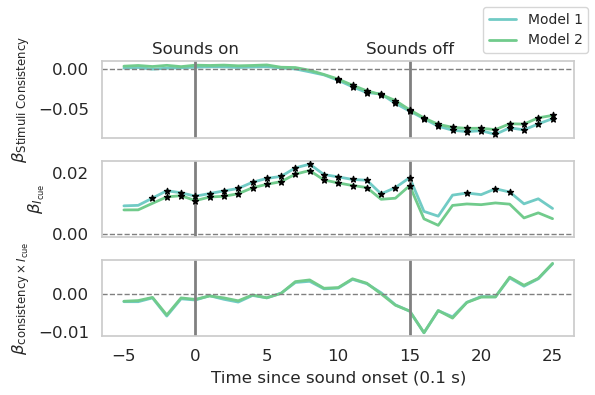

In [4]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Files for the two models
file_names = ["regression_results_2sidelearning_did", "regression_results_cuedsidelearning"]
model_labels = ["Model 1", "Model 2"]
colors = ["#71cbc5", "#71cb8c"]  # Model 1 and Model 2 colors

# Predictors we care about
plot_predictors = ["stimulus_consistency", "cue_surprise", "stimulus_consistency:cue_surprise"]
y_labels = [
    r"$\beta_{\text{Stimuli Consistency}}$",
    r"$\beta_{I_\text{cue}}$",
    r"$\beta_{\text{consistency} \times I_\text{cue}}$"
]

# Create figure with 3 vertical subplots
fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)

for i, (ax, coef_name, ylabel) in enumerate(zip(axes, plot_predictors, y_labels)):
    max_val_for_asterisk = -np.inf

    # Plot each model
    for file_name, label, color in zip(file_names, model_labels, colors):
        with open(f"{file_name}.pkl", "rb") as f:
            results_dict = pickle.load(f)

        coef_matrix = results_dict["coefficients"][coef_name]
        pval_matrix = results_dict["p_values"][coef_name]

        # Original time bins
        t = np.arange(coef_matrix.shape[0])
        t_shifted = t - 30

        # Only keep points where shifted x is between -5 and 25
        mask = (t_shifted >= -5) & (t_shifted <= 25)
        t_plot = t_shifted[mask]
        coefs_plot = coef_matrix[mask]
        pvals_plot = pval_matrix[mask]

        # Update max value for placing asterisks
        max_val_for_asterisk = max(max_val_for_asterisk, coefs_plot.max())

        # Plot line
        ax.plot(t_plot, coefs_plot, color=color, linewidth=2, label=label)

        # Add red asterisks for significant points
        sig_mask = pvals_plot < 0.05
        ax.scatter(t_plot[sig_mask], coefs_plot[sig_mask],
                   color='black', s=20, marker='*', zorder=5)

    # Vertical lines for sound on/off as solid gray
    ax.axvline(0, linestyle='-', color='gray', linewidth=2)
    ax.axvline(15, linestyle='-', color='gray', linewidth=2)

    # Only add event labels for the first subplot
    if i == 0:
        ax.text(0, max_val_for_asterisk + 0.01, "Sounds on", ha='center', va='bottom', fontsize=12)
        ax.text(15, max_val_for_asterisk + 0.01, "Sounds off", ha='center', va='bottom', fontsize=12)

    # Axis labels
    ax.set_ylabel(ylabel)
    ax.axhline(0, linestyle='--', color='gray', linewidth=1)

    # Remove grid lines
    ax.grid(False)

for ax in axes:
    ax.tick_params(axis='both', labelsize=12)

# X-axis label
axes[-1].set_xlabel("Time since sound onset (0.1 s)")

# Legend for the figure with larger font
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("sound_stage_binnedtime.pdf", bbox_inches="tight")
plt.show()


# cue stage

In [63]:

# ------------------------
# Functions
# ------------------------
def cum_counts_cued(block_df):
    block_df['cumA_beforetrial_cued'] = block_df['is_cued_A'].cumsum().shift(1, fill_value=0) + 1
    block_df['cumB_beforetrial_cued'] = block_df['is_cued_B'].cumsum().shift(1, fill_value=0) + 1
    block_df['cumA_aftertrial_cued'] = block_df['is_cued_A'].cumsum() + 1
    block_df['cumB_aftertrial_cued'] = block_df['is_cued_B'].cumsum() + 1
    return block_df

def cum_counts_bilateral(block_df):
    block_df['cumA_beforetrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum().shift(1, fill_value=0) + 1
    block_df['cumB_beforetrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum().shift(1, fill_value=0) + 1
    block_df['cumA_aftertrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum() + 1
    block_df['cumB_aftertrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum() + 1
    return block_df

def process_folder(folder, subject_id):
    """Process one folder and return a DataFrame with pupil data and computed variables."""
    baseline_file = os.path.join(eye_directory, folder, 'baseline_with_pupilSound_response.csv')
    if not os.path.exists(baseline_file):
        print(f"⚠️ Missing file for {folder}, skipping")
        return None
    
    pupil = pd.read_csv(baseline_file)
    participant = DataAnalyze_new(folder, main_directory)
    print(f"📂 Loading data from {folder}")

    # DEBUG: Check initial sizes
    print(f"🔍 DEBUG: Initial sizes")
    print(f"  pupil (baseline file): {len(pupil)} rows")
    print(f"  participant.log_data: {len(participant.log_data)} rows")

    # Add metadata
    pupil['subject'] = subject_id
    pupil['block_index'] = participant.log_data['block_index']
    pupil['trial_index_within_block'] = participant.log_data['trial_index_within_block']
    pupil['stimulus_consistency'] = participant.log_data['stimulus_consistency']
    pupil['block_entropy'] = participant.log_data['block_entropy']
    pupil['performance'] = participant.log_data['performance']


    left_stim = participant.log_data['stimulus'].str[0]
    right_stim = participant.log_data['stimulus'].str[2]
    cued_stim = np.where(participant.log_data['cue_direction']=='left', left_stim, right_stim)
    noncued_stim = np.where(participant.log_data['cue_direction']=='right', left_stim, right_stim)

    stiminfo = pd.DataFrame({
        'block_index': participant.log_data['block_index'],
        'left_stim': left_stim,
        'right_stim': right_stim,
        'cued_stim': pd.Series(cued_stim),
        'noncued_stim': pd.Series(noncued_stim)
    })

    # print(f"🔍 DEBUG: cuedstim before groupby: {len(cuedstim)} rows")


    # ---- Cued counts ----
    cuedstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                             'cued_stim': cued_stim})
    cuedstim['is_cued_A'] = (cuedstim['cued_stim']=='A').astype(int)
    cuedstim['is_cued_B'] = (cuedstim['cued_stim']=='B').astype(int)
    cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
    cuedstim['priorAprob_cued'] = cuedstim['cumA_beforetrial_cued'] / (cuedstim['cumA_beforetrial_cued'] + cuedstim['cumB_beforetrial_cued'])
    cuedstim['priorBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_beforetrial_cued'], row['cumB_beforetrial_cued']), axis=1)
    cuedstim['postBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_aftertrial_cued'], row['cumB_aftertrial_cued']), axis=1)
    pupil['learning_surprise_cued'] = cuedstim.apply(lambda row: kl_beta(row['priorBeta_cued'], row['postBeta_cued']), axis=1)
    pupil['cuedStim_surprise_cued'] = np.where(stiminfo['cued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))
    pupil['noncuedStim_surprise_cued'] = np.where(stiminfo['noncued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))

    # ---- Bilateral counts ----
    bilateralstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                                  'left_stim': left_stim, 'right_stim': right_stim})
    bilateralstim['is_left_A'] = (bilateralstim['left_stim']=='A').astype(int)
    bilateralstim['is_left_B'] = (bilateralstim['left_stim']=='B').astype(int)
    bilateralstim['is_right_A'] = (bilateralstim['right_stim']=='A').astype(int)
    bilateralstim['is_right_B'] = (bilateralstim['right_stim']=='B').astype(int)
    bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)
    bilateralstim['priorAprob_bi'] = bilateralstim['cumA_beforetrial_bi'] / (bilateralstim['cumA_beforetrial_bi'] + bilateralstim['cumB_beforetrial_bi'])
    bilateralstim['priorBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_beforetrial_bi'], row['cumB_beforetrial_bi']), axis=1)
    bilateralstim['postBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_aftertrial_bi'], row['cumB_aftertrial_bi']), axis=1)
    pupil['learning_surprise_bi'] = bilateralstim.apply(lambda row: kl_beta(row['priorBeta_bi'], row['postBeta_bi']), axis=1)
    pupil['cuedStim_surprise_bi'] = np.where(stiminfo['cued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))
    pupil['noncuedStim_surprise_bi'] = np.where(stiminfo['noncued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))

    # ---- Cue surprise ----
    participant.log_data = get_information_gain(participant.log_data)
    cue = participant.log_data['cue_direction']
    subjective_leftcue_prob = participant.log_data['cue_learning_prior'].apply(lambda b: b.mean())
    pupil['cue_learning_surprise'] = participant.log_data.apply(lambda row: kl_beta(row['cue_learning_prior'], row['cue_learning_posterior']), axis=1)
    cue_prob = np.where(cue=='left', subjective_leftcue_prob, 1-subjective_leftcue_prob)
    pupil['cue_surprise'] = -np.log(cue_prob)

    return pupil

In [64]:
pupil_data_list = []
subject_count = 0

for folder in yes_folders:
    subject_count += 1
    pupil = process_folder(folder, subject_count)
    if pupil is not None:
        pupil_data_list.append(pupil)

all_pupil = pd.concat(pupil_data_list, ignore_index=True)
all_pupil['max_pupilcue_Ratio'] = all_pupil['max_pupilCue'] / all_pupil['baseline']
all_pupil = all_pupil[all_pupil['performance']=="Correct"].copy()

# Keep only correct trials
all_pupil_correct = all_pupil.copy()

# Get list of subject IDs that survived
subjects_present = all_pupil_correct['subject'].unique()

# Map subject IDs to folders
subject_folder_map = {i+1: folder for i, folder in enumerate(yes_folders)}

# Check which folders are missing
missing_folders = [folder for i, folder in subject_folder_map.items() if i not in subjects_present]

print("Folders with usable data:", [subject_folder_map[i] for i in subjects_present])
print("Folders completely missing / dropped:", missing_folders)


📂 Loading data from 25-09-29-1238_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_3811986/4046401907.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_3811986/4046401907.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-09-30-1142_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_3811986/4046401907.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_3811986/4046401907.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-09-30-1338_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


...

📂 Loading data from 25-11-07-1401_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_3811986/4046401907.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_3811986/4046401907.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)
/scratch/yd2103/pd_data/functions.py:912: DtypeWarning: Columns

📂 Loading data from 25-11-07-1456_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_3811986/4046401907.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_3811986/4046401907.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


Folders with usable data: ['25-09-29-1238_setting0', '25-09-30-1142_setting0', '25-09-30-1338_setting0', '25-09-30-1427_setting0', '25-09-30-1530_setting0', '25-10-01-1417_setting0', '25-10-07-1233_setting0', '25-10-07-1328_setting0', '25-10-07-1513_setting0', '25-10-09-1303_setting0', '25-10-17-1206_setting0', '25-10-20-1204_setting0', '25-10-20-1257_setting0', '25-10-21-1446_setting0', '25-10-22-1358_setting0', '25-10-23-1258_setting0', '25-10-24-1302_setting0', '25-10-27-1254_setting0', '25-10-30-1254_setting0', '25-10-31-1350_setting0', '25-11-03-1100_setting0', '25-11-03-1151_setting0', '25-11-03-1301_setting0', '25-11-04-1214_setting0', '25-11-04-1404_setting0', '25-11-05-1407_setting0', '25-11-05-1457_setting0', '25-11-06-1302_setting0', '25-11-07-1401_setting0', '25-11-07-1456_setting0']
Folders completely missing / dropped: []


In [65]:

# --- Function to fit mixed-effects model ---
def fit_pupil_model(all_pupil, predictors):
    formula_cols = ["max_pupilcue_Ratio"] + predictors
    for col in formula_cols:
        all_pupil[col] = pd.to_numeric(all_pupil[col], errors='coerce')
    if 'stimulus_consistency' in predictors:
        all_pupil['stimulus_consistency'] = all_pupil['stimulus_consistency'].astype(int)
    clean_data = all_pupil.dropna(subset=formula_cols)
    formula = "max_pupilcue_Ratio ~ " + " + ".join(predictors)
    model = smf.mixedlm(formula, clean_data, groups=clean_data["subject"]).fit(reml=True)
    return model

# --- Fit the model ---
model_preds = {"1": ["cue_surprise", "cue_learning_surprise"]}
models = {name: fit_pupil_model(all_pupil, preds) for name, preds in model_preds.items()}
model = models['1']

/scratch/yd2103/.conda/envs/pdData_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/tmp/ipykernel_3811986/1727319049.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(labels_latex, rotation=30, ha='right', size=14)


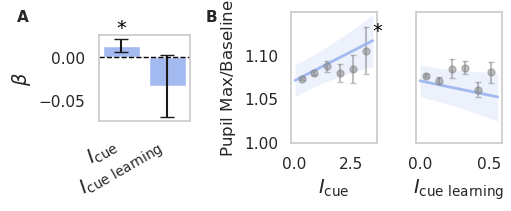

In [66]:
import statsmodels.api as sm

# --- Plotting parameters ---
plot_predictors = ["cue_surprise", "cue_learning_surprise"]
y_var = "max_pupilcue_Ratio"
labels_latex = [r"$I_\text{cue}$", r"$I_{\text{cue learning}}$"]

coefs = model.params.loc[plot_predictors]
conf_int = model.conf_int().loc[plot_predictors]
pvals = model.pvalues.loc[plot_predictors]

# --- Create figure ---
fig = plt.figure(figsize=(5, 2), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, width_ratios=[0.6, 2], wspace=0.1, figure=fig)

# --- Panel A: Beta coefficients ---
ax_a = fig.add_subplot(gs[0])
bars = ax_a.bar(coefs.index, coefs.values,
                color="#a3baf0",
                yerr=(conf_int[1] - conf_int[0])/2,
                capsize=5)
for bar, p in zip(bars, pvals):
    if p < 0.05:
        height = bar.get_height()
        ax_a.text(bar.get_x() + bar.get_width()/2, height + 0.01, "*", ha='center', va='bottom', fontsize=14, color='black')

ax_a.set_ylabel(r"$\beta$", size=14)
ax_a.set_xticklabels(labels_latex, rotation=30, ha='right', size=14)
ax_a.axhline(0, color='black', linestyle='--', linewidth=1)
ax_a.grid(False)

# --- Panel B: Scatter plots with binned mean ± SEM and regression line ---
gs_b = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.1)
ax_b1 = fig.add_subplot(gs_b[0])
ax_b2 = fig.add_subplot(gs_b[1], sharey=ax_b1)

for ax, reg, label, pval in zip([ax_b1, ax_b2], plot_predictors, labels_latex, pvals):
    x = all_pupil[reg].values
    y = all_pupil[y_var].values

    # --- Binning ---
    n_bins = 6
    bins = np.linspace(np.nanmin(x), np.nanmax(x), n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    y_mean = []
    y_sem = []
    for i in range(n_bins):
        if i < n_bins - 1:
            y_bin = y[(x >= bins[i]) & (x < bins[i+1])]
        else:  # include rightmost edge for last bin
            y_bin = y[(x >= bins[i]) & (x <= bins[i+1])]
        y_bin = y_bin[~np.isnan(y_bin)]
        if len(y_bin) > 0:
            y_mean.append(np.mean(y_bin))
            y_sem.append(np.std(y_bin, ddof=1)/np.sqrt(len(y_bin)))
        else:
            y_mean.append(np.nan)
            y_sem.append(np.nan)

    # --- Plot binned mean ± SEM ---
    ax.errorbar(bin_centers, y_mean, yerr=y_sem, fmt='o', color="gray", alpha=0.5, markersize=5, capsize=2)

    # --- 95% CI for LME fixed-effect prediction ---
    beta_0 = model.params["Intercept"]
    beta_1 = model.params[reg]

    x_range = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_fit = beta_0 + beta_1 * x_range
    ax.plot(x_range, y_fit, color="#a3baf0", linewidth=2, label="LME fixed-effect")

    cov = model.cov_params().loc[
        ["Intercept", reg],
        ["Intercept", reg]
    ].values

    X_pred = np.column_stack([np.ones_like(x_range), x_range])
    var_pred = np.sum(X_pred @ cov * X_pred, axis=1)
    se_pred = np.sqrt(var_pred)

    ci_lower = y_fit - 1.96 * se_pred
    ci_upper = y_fit + 1.96 * se_pred

    ax.fill_between(
        x_range,
        ci_lower,
        ci_upper,
        color="#a3baf0",
        alpha=0.2,
        linewidth=0
    )


    # --- Significance asterisk ---
    if pval < 0.05:
        ax.text(x_range[-1], y_fit[-1], "*", color="black", fontsize=14, va='bottom', ha='left')

    # --- Labels & grid ---
    ax.set_xlabel(label, size=14)
    ax.set_ylabel(r"$\mathrm{Pupil\ Max / Baseline}$" if ax == ax_b1 else "")
    ax.grid(False)

    # --- Auto y-limits based on binned data + SEM ---
    y_all = np.array(y_mean)
    y_err = np.array(y_sem)
    y_min = np.nanmin(y_all - y_err)
    y_max = np.nanmax(y_all + y_err)
    ax.set_ylim(y_min*0.95, y_max*1.05)

# Remove y-axis from right scatter plot
ax_b2.get_yaxis().set_visible(False)

# --- Add panel labels ---
label_kw = dict(fontsize=11, fontweight="bold", va="top", ha="left", clip_on=False)
ax_a.text(-0.9, 1.3, "A", transform=ax_a.transAxes, **label_kw)
ax_b1.text(-1, 1.02, "B", transform=ax_b1.transAxes, **label_kw)

# --- Save figure ---
plt.savefig("cue_stage.pdf", bbox_inches="tight")
plt.show()

# sound stage

In [2]:

# ------------------------
# Functions
# ------------------------
def cum_counts_cued(block_df):
    block_df['cumA_beforetrial_cued'] = block_df['is_cued_A'].cumsum().shift(1, fill_value=0) + 1
    block_df['cumB_beforetrial_cued'] = block_df['is_cued_B'].cumsum().shift(1, fill_value=0) + 1
    block_df['cumA_aftertrial_cued'] = block_df['is_cued_A'].cumsum() + 1
    block_df['cumB_aftertrial_cued'] = block_df['is_cued_B'].cumsum() + 1
    return block_df

def cum_counts_bilateral(block_df):
    block_df['cumA_beforetrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum().shift(1, fill_value=0) + 1
    block_df['cumB_beforetrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum().shift(1, fill_value=0) + 1
    block_df['cumA_aftertrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum() + 1
    block_df['cumB_aftertrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum() + 1
    return block_df

def process_folder(folder, subject_id):
    """Process one folder and return a DataFrame with pupil data and computed variables."""
    baseline_file = os.path.join(eye_directory, folder, 'baseline_with_pupilSound.csv')
    if not os.path.exists(baseline_file):
        print(f"⚠️ Missing file for {folder}, skipping")
        return None
    
    pupil = pd.read_csv(baseline_file)
    participant = DataAnalyze_new(folder, main_directory)
    print(f"📂 Loading data from {folder}")

    # DEBUG: Check initial sizes
    print(f"🔍 DEBUG: Initial sizes")
    print(f"  pupil (baseline file): {len(pupil)} rows")
    print(f"  participant.log_data: {len(participant.log_data)} rows")

    # Add metadata
    pupil['subject'] = subject_id
    pupil['block_index'] = participant.log_data['block_index']
    pupil['trial_index_within_block'] = participant.log_data['trial_index_within_block']
    pupil['stimulus_consistency'] = participant.log_data['stimulus_consistency']
    pupil['block_entropy'] = participant.log_data['block_entropy']
    pupil['performance'] = participant.log_data['performance']


    left_stim = participant.log_data['stimulus'].str[0]
    right_stim = participant.log_data['stimulus'].str[2]
    cued_stim = np.where(participant.log_data['cue_direction']=='left', left_stim, right_stim)
    noncued_stim = np.where(participant.log_data['cue_direction']=='right', left_stim, right_stim)

    stiminfo = pd.DataFrame({
        'block_index': participant.log_data['block_index'],
        'left_stim': left_stim,
        'right_stim': right_stim,
        'cued_stim': pd.Series(cued_stim),
        'noncued_stim': pd.Series(noncued_stim)
    })

    # print(f"🔍 DEBUG: cuedstim before groupby: {len(cuedstim)} rows")


    # ---- Cued counts ----
    cuedstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                             'cued_stim': cued_stim})
    cuedstim['is_cued_A'] = (cuedstim['cued_stim']=='A').astype(int)
    cuedstim['is_cued_B'] = (cuedstim['cued_stim']=='B').astype(int)
    cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
    cuedstim['priorAprob_cued'] = cuedstim['cumA_beforetrial_cued'] / (cuedstim['cumA_beforetrial_cued'] + cuedstim['cumB_beforetrial_cued'])
    cuedstim['priorBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_beforetrial_cued'], row['cumB_beforetrial_cued']), axis=1)
    cuedstim['postBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_aftertrial_cued'], row['cumB_aftertrial_cued']), axis=1)
    pupil['learning_surprise_cued'] = cuedstim.apply(lambda row: kl_beta(row['priorBeta_cued'], row['postBeta_cued']), axis=1)
    pupil['cuedStim_surprise_cued'] = np.where(stiminfo['cued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))
    pupil['noncuedStim_surprise_cued'] = np.where(stiminfo['noncued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))

    # ---- Bilateral counts ----
    bilateralstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                                  'left_stim': left_stim, 'right_stim': right_stim})
    bilateralstim['is_left_A'] = (bilateralstim['left_stim']=='A').astype(int)
    bilateralstim['is_left_B'] = (bilateralstim['left_stim']=='B').astype(int)
    bilateralstim['is_right_A'] = (bilateralstim['right_stim']=='A').astype(int)
    bilateralstim['is_right_B'] = (bilateralstim['right_stim']=='B').astype(int)
    bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)
    bilateralstim['priorAprob_bi'] = bilateralstim['cumA_beforetrial_bi'] / (bilateralstim['cumA_beforetrial_bi'] + bilateralstim['cumB_beforetrial_bi'])
    bilateralstim['priorBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_beforetrial_bi'], row['cumB_beforetrial_bi']), axis=1)
    bilateralstim['postBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_aftertrial_bi'], row['cumB_aftertrial_bi']), axis=1)
    pupil['learning_surprise_bi'] = bilateralstim.apply(lambda row: kl_beta(row['priorBeta_bi'], row['postBeta_bi']), axis=1)
    pupil['cuedStim_surprise_bi'] = np.where(stiminfo['cued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))
    pupil['noncuedStim_surprise_bi'] = np.where(stiminfo['noncued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))

    # ---- Cue surprise ----
    participant.log_data = get_information_gain(participant.log_data)
    cue = participant.log_data['cue_direction']
    subjective_leftcue_prob = participant.log_data['cue_learning_posterior'].apply(lambda b: b.mean())
    cue_prob = np.where(cue=='left', subjective_leftcue_prob, 1-subjective_leftcue_prob)
    pupil['cue_surprise'] = -np.log(cue_prob)

    return pupil

pupil_data_list = []
subject_count = 0

for folder in yes_folders:
    subject_count += 1
    pupil = process_folder(folder, subject_count)
    if pupil is not None:
        pupil_data_list.append(pupil)

# Combine all subjects
all_pupil = pd.concat(pupil_data_list, ignore_index=True)

# Create pupil ratio
all_pupil["max_pupilRatio"] = all_pupil["max_pupilSound"] / all_pupil["baseline"]

# Keep only correct trials
all_pupil_correct = all_pupil[all_pupil["performance"] == "Correct"].copy()

# ---- Check which subjects survived ----
subjects_present = all_pupil_correct["subject"].unique()

# Map subject IDs to folders
subject_folder_map = {i + 1: folder for i, folder in enumerate(yes_folders)}

# Find missing folders
missing_folders = [
    folder for i, folder in subject_folder_map.items()
    if i not in subjects_present
]

print("Folders with usable data:", [subject_folder_map[i] for i in subjects_present])
print("Folders completely missing / dropped:", missing_folders)


📂 Loading data from 25-09-29-1238_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1780290/605556742.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1780290/605556742.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-09-30-1142_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1780290/605556742.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1780290/605556742.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-09-30-1338_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


...

📂 Loading data from 25-11-07-1401_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1780290/605556742.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1780290/605556742.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)
/scratch/yd2103/pd_data/functions.py:912: DtypeWarning: Columns (

📂 Loading data from 25-11-07-1456_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_1780290/605556742.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_1780290/605556742.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


Folders with usable data: ['25-09-29-1238_setting0', '25-09-30-1142_setting0', '25-09-30-1338_setting0', '25-09-30-1427_setting0', '25-09-30-1530_setting0', '25-10-01-1417_setting0', '25-10-07-1233_setting0', '25-10-07-1328_setting0', '25-10-07-1513_setting0', '25-10-09-1303_setting0', '25-10-17-1206_setting0', '25-10-20-1204_setting0', '25-10-20-1257_setting0', '25-10-21-1446_setting0', '25-10-22-1358_setting0', '25-10-23-1258_setting0', '25-10-24-1302_setting0', '25-10-27-1254_setting0', '25-10-30-1254_setting0', '25-10-31-1350_setting0', '25-11-03-1100_setting0', '25-11-03-1151_setting0', '25-11-03-1301_setting0', '25-11-04-1214_setting0', '25-11-04-1404_setting0', '25-11-05-1407_setting0', '25-11-05-1457_setting0', '25-11-06-1302_setting0', '25-11-07-1401_setting0', '25-11-07-1456_setting0']
Folders completely missing / dropped: []


In [3]:

# ------------------------
# Fit mixed-effects model
# ------------------------
def fit_pupil_model(all_pupil, predictors):
    # --- Extract actual column names used in predictors ---
    base_cols = set()
    for p in predictors:
        if "*" in p:
            base_cols.update([s.strip() for s in p.split("*")])
        elif ":" in p:
            base_cols.update([s.strip() for s in p.split(":")])
        else:
            base_cols.add(p)

    formula_cols = ["max_pupilRatio"] + list(base_cols)

    # --- Ensure numeric ---
    for col in formula_cols:
        all_pupil[col] = pd.to_numeric(all_pupil[col], errors="coerce")

    # --- Cast stimulus_consistency if present ---
    if "stimulus_consistency" in base_cols:
        all_pupil["stimulus_consistency"] = all_pupil["stimulus_consistency"].astype(int)

    # --- Drop NA only on real columns ---
    clean_data = all_pupil.dropna(subset=formula_cols)

    # --- Build formula ---
    formula = "max_pupilRatio ~ " + " + ".join(predictors)

    model = smf.mixedlm(
        formula,
        clean_data,
        groups=clean_data["subject"]
    ).fit(reml=True)

    return model

# ---- Define predictor sets ----
model_preds = {
    "1": [
        "stimulus_consistency * cue_surprise",
        "learning_surprise_cued",
        "cuedStim_surprise_cued",
        "noncuedStim_surprise_cued",
    ],
    "2": [
        "stimulus_consistency * cue_surprise",
        "learning_surprise_bi",
        "cuedStim_surprise_bi",
        "noncuedStim_surprise_bi",
    ],
}

# ---- Fit and print models ----
models = {}
for name, preds in model_preds.items():
    models[name] = fit_pupil_model(all_pupil_correct, preds)
    print(f"\n===== Model {name} =====")
    print(models[name].summary())



===== Model 1 =====
                   Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      max_pupilRatio
No. Observations:       7926         Method:                  REML          
No. Groups:             30           Scale:                   0.0291        
Min. group size:        252          Log-Likelihood:          2678.8313     
Max. group size:        269          Converged:               Yes           
Mean group size:        264.2                                               
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          1.168    0.023 51.282 0.000  1.124  1.213
stimulus_consistency              -0.039    0.007 -5.443 0.000 -0.053 -0.025
cue_surprise                       0.023    0.009  2.675 0.007  0.006  0.04

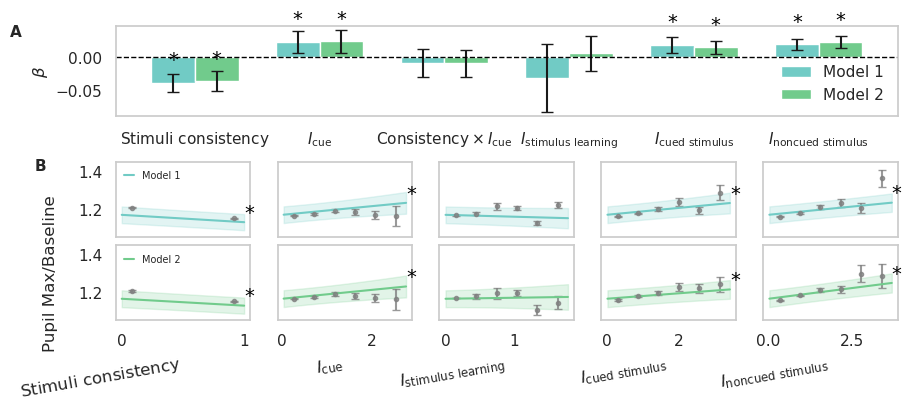

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------
# 1) Setup Variables & Colors
# ------------------------
colors = ["#71cbc5", "#71cb8c"]  # Model 1 and Model 2

terms_m1 = [
    "stimulus_consistency",
    "cue_surprise",
    "stimulus_consistency:cue_surprise",
    "learning_surprise_cued",
    "cuedStim_surprise_cued",
    "noncuedStim_surprise_cued"
]

terms_m2 = [
    "stimulus_consistency",
    "cue_surprise",
    "stimulus_consistency:cue_surprise",
    "learning_surprise_bi",
    "cuedStim_surprise_bi",
    "noncuedStim_surprise_bi"
]

labels_latex = [
    r"$\mathrm{Stimuli\ consistency}$",
    r"$I_\mathrm{cue}$",
    r"$\mathrm{Consistency}\times I_\mathrm{cue}$",
    r"$I_{\mathrm{stimulus\ learning}}$",
    r"$I_{\mathrm{cued\ stimulus}}$",
    r"$I_{\mathrm{noncued\ stimulus}}$"
]

# Remove interaction term for scatter plots
scatter_idx = [0, 1, 3, 4, 5]
terms_m1_scatter = [terms_m1[i] for i in scatter_idx]
terms_m2_scatter = [terms_m2[i] for i in scatter_idx]
labels_scatter = [labels_latex[i] for i in scatter_idx]

# ------------------------
# 2) Extract coefficients for Panel A
# ------------------------
coefs1 = models["1"].params.loc[terms_m1]
ci1 = models["1"].conf_int().loc[terms_m1]
pvals1 = models["1"].pvalues.loc[terms_m1]

coefs2 = models["2"].params.loc[terms_m2]
ci2 = models["2"].conf_int().loc[terms_m2]
pvals2 = models["2"].pvalues.loc[terms_m2]

yerr1 = (ci1[1] - ci1[0]) / 2
yerr2 = (ci2[1] - ci2[0]) / 2

# ------------------------
# 3) Helper Functions
# ------------------------
def add_asterisks_bars(ax, bars, pvals, offset=0.02, fontsize=14):
    for bar, p in zip(bars, pvals):
        if p < 0.05:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + offset,
                    "*", ha="center", va="bottom", fontsize=fontsize, color="black")

# ------------------------
# 4) Figure Layout
# ------------------------
n_cols = 5
fig = plt.figure(figsize=(9, 4), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=n_cols, height_ratios=[1.2, 1, 1])

# ------------------------
# 5) Panel A: Bar Plot
# ------------------------
ax_bar = fig.add_subplot(gs[0, :])
xpos = np.arange(len(labels_latex))
bar_w = 0.35

bars1 = ax_bar.bar(xpos - bar_w / 2, coefs1.values, width=bar_w, yerr=yerr1.values,
                   capsize=4, color=colors[0], label="Model 1")
bars2 = ax_bar.bar(xpos + bar_w / 2, coefs2.values, width=bar_w, yerr=yerr2.values,
                   capsize=4, color=colors[1], label="Model 2")

add_asterisks_bars(ax_bar, bars1, pvals1)
add_asterisks_bars(ax_bar, bars2, pvals2)

ax_bar.axhline(0, color="black", linewidth=1, linestyle="--")
ax_bar.set_xticks(xpos)
ax_bar.set_xticklabels(labels_latex, rotation=0, ha="center")
ax_bar.set_ylabel(r"$\beta$")
ax_bar.legend(frameon=False)
ax_bar.grid(False)

# ------------------------
# 6) Panel B: Scatter Plots with binned mean ± SEM and LME fixed-effect regression + 95% CI
# ------------------------
y_min, y_max = 1.05, 1.45  # y-axis limits

pvals1_scatter = [pvals1.loc[terms_m1[i]] for i in scatter_idx]
pvals2_scatter = [pvals2.loc[terms_m2[i]] for i in scatter_idx]

for i in range(n_cols):
    # --- Row 1: Model 1 ---
    ax1 = fig.add_subplot(gs[1, i])
    ax1.grid(False)
    ax1.set_ylim(y_min, y_max)

    predictor = terms_m1_scatter[i]
    if predictor in all_pupil_correct.columns:
        x_data = all_pupil_correct[predictor].values
        y_data = all_pupil_correct["max_pupilRatio"].values

        # --- Binning ---
        n_bins = 6
        bins = np.linspace(np.nanmin(x_data), np.nanmax(x_data), n_bins + 1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        y_mean, y_sem = [], []

        for j in range(n_bins):
            if j < n_bins - 1:
                y_bin = y_data[(x_data >= bins[j]) & (x_data < bins[j+1])]
            else:
                y_bin = y_data[(x_data >= bins[j]) & (x_data <= bins[j+1])]
            y_bin = y_bin[~np.isnan(y_bin)]
            if len(y_bin) > 0:
                y_mean.append(np.mean(y_bin))
                y_sem.append(np.std(y_bin, ddof=1)/np.sqrt(len(y_bin)))
            else:
                y_mean.append(np.nan)
                y_sem.append(np.nan)

        # Plot binned mean ± SEM
        y_mean = np.array(y_mean)
        y_sem = np.array(y_sem)
        valid = ~np.isnan(y_mean) & ~np.isnan(y_sem)
        ax1.errorbar(bin_centers[valid], y_mean[valid], yerr=y_sem[valid], 
                     fmt='o', color="gray", alpha=0.8, markersize=3, capsize=3)

        # --- Regression line + 95% CI (fixed effects) ---
        intercept = models["1"].params["Intercept"]
        slope = models["1"].params[predictor]
        cov = models["1"].cov_params()

        x_range = np.linspace(np.nanmin(x_data), np.nanmax(x_data), 100)
        y_fit = intercept + slope * x_range
        se_fit = np.sqrt(
            cov.loc["Intercept", "Intercept"] + 
            (x_range**2) * cov.loc[predictor, predictor] + 
            2 * x_range * cov.loc["Intercept", predictor]
        )
        ci_lower = y_fit - 1.96 * se_fit
        ci_upper = y_fit + 1.96 * se_fit

        ax1.plot(x_range, y_fit, color=colors[0], linewidth=1.5,
                 label="Model 1" if i==0 else None)
        ax1.fill_between(x_range, ci_lower, ci_upper, color=colors[0], alpha=0.2)

        # Significance asterisk
        if pvals1_scatter[i] < 0.05:
            ax1.text(x_range[-1], y_fit[-1], "*", color="black", fontsize=14, va='bottom', ha='left')

    ax1.set_xlabel("")
    ax1.set_xticklabels([])
    ax1.set_ylabel("")
    if i != 0:
        ax1.set_yticklabels([])
    if i == 0:
        ax1.legend(loc='upper left', frameon=False, fontsize=7, handlelength=1)

    # --- Row 2: Model 2 ---
    ax2 = fig.add_subplot(gs[2, i], sharey=ax1)
    ax2.grid(False)
    ax2.set_ylim(y_min, y_max)

    predictor = terms_m2_scatter[i]
    if predictor in all_pupil_correct.columns:
        x_data = all_pupil_correct[predictor].values
        y_data = all_pupil_correct["max_pupilRatio"].values

        # --- Binning ---
        n_bins = 6
        bins = np.linspace(np.nanmin(x_data), np.nanmax(x_data), n_bins + 1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        y_mean, y_sem = [], []

        for j in range(n_bins):
            if j < n_bins - 1:
                y_bin = y_data[(x_data >= bins[j]) & (x_data < bins[j+1])]
            else:
                y_bin = y_data[(x_data >= bins[j]) & (x_data <= bins[j+1])]
            y_bin = y_bin[~np.isnan(y_bin)]
            if len(y_bin) > 0:
                y_mean.append(np.mean(y_bin))
                y_sem.append(np.std(y_bin, ddof=1)/np.sqrt(len(y_bin)))
            else:
                y_mean.append(np.nan)
                y_sem.append(np.nan)

        # Plot binned mean ± SEM
        y_mean = np.array(y_mean)
        y_sem = np.array(y_sem)
        valid = ~np.isnan(y_mean) & ~np.isnan(y_sem)
        ax2.errorbar(bin_centers[valid], y_mean[valid], yerr=y_sem[valid], 
                     fmt='o', color="gray", alpha=0.8, markersize=3, capsize=3)

        # --- Regression line + 95% CI (fixed effects) ---
        intercept = models["2"].params["Intercept"]
        slope = models["2"].params[predictor]
        cov = models["2"].cov_params()

        x_range = np.linspace(np.nanmin(x_data), np.nanmax(x_data), 100)
        y_fit = intercept + slope * x_range
        se_fit = np.sqrt(
            cov.loc["Intercept", "Intercept"] + 
            (x_range**2) * cov.loc[predictor, predictor] + 
            2 * x_range * cov.loc["Intercept", predictor]
        )
        ci_lower = y_fit - 1.96 * se_fit
        ci_upper = y_fit + 1.96 * se_fit

        ax2.plot(x_range, y_fit, color=colors[1], linewidth=1.5,
                 label="Model 2" if i==0 else None)
        ax2.fill_between(x_range, ci_lower, ci_upper, color=colors[1], alpha=0.2)

        # Significance asterisk
        if pvals2_scatter[i] < 0.05:
            ax2.text(x_range[-1], y_fit[-1], "*", color="black", fontsize=14, va='bottom', ha='left')

    ax2.set_xlabel(labels_scatter[i], fontsize=12, rotation=10, ha="right")
    ax2.set_ylabel("")
    if i != 0:
        ax2.set_yticklabels([])
    if i == 0:
        ax2.legend(loc='upper left', frameon=False, fontsize=7, handlelength=1)

# ------------------------
# 7) Single shared y-label for Panel B
# ------------------------
fig.text(0.05, 0.33, "Pupil Max/Baseline", rotation="vertical",
         va="center", ha="center", fontsize=12)

# ------------------------
# 8) Panel Labels A & B
# ------------------------
label_kw = dict(fontsize=11, fontweight="bold", va="top", ha="left", clip_on=False)
ax_bar.text(-0.135, 1.02, "A", transform=ax_bar.transAxes, **label_kw)
ax1_first = fig.axes[1]
ax1_first.text(-0.6, 1.05, "B", transform=ax1_first.transAxes, **label_kw)

plt.savefig("sound_stage.pdf", bbox_inches="tight")
plt.show()


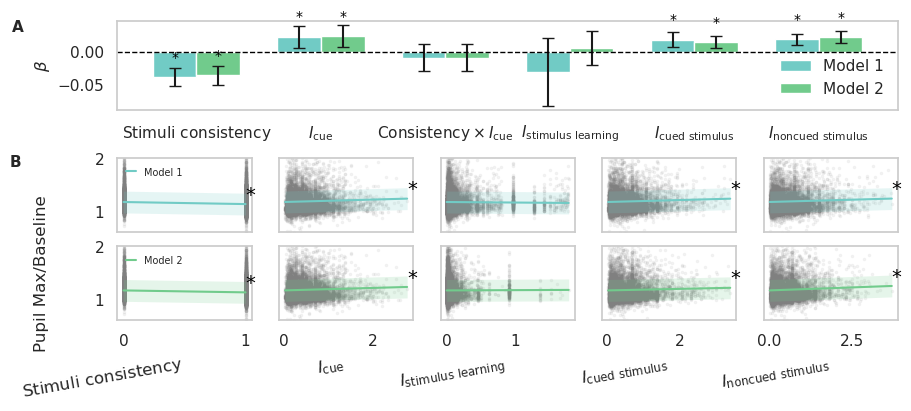

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
# 1) Setup Variables & Colors
# ------------------------
colors = ["#71cbc5", "#71cb8c"]  # Model 1 and Model 2

terms_m1 = [
    "stimulus_consistency",
    "cue_surprise",
    "stimulus_consistency:cue_surprise",
    "learning_surprise_cued",
    "cuedStim_surprise_cued",
    "noncuedStim_surprise_cued"
]

terms_m2 = [
    "stimulus_consistency",
    "cue_surprise",
    "stimulus_consistency:cue_surprise",
    "learning_surprise_bi",
    "cuedStim_surprise_bi",
    "noncuedStim_surprise_bi"
]

labels_latex = [
    r"$\mathrm{Stimuli\ consistency}$",
    r"$I_\mathrm{cue}$",
    r"$\mathrm{Consistency}\times I_\mathrm{cue}$",
    r"$I_{\mathrm{stimulus\ learning}}$",
    r"$I_{\mathrm{cued\ stimulus}}$",
    r"$I_{\mathrm{noncued\ stimulus}}$"
]

# Remove interaction term for scatter plots
scatter_idx = [0, 1, 3, 4, 5]
terms_m1_scatter = [terms_m1[i] for i in scatter_idx]
terms_m2_scatter = [terms_m2[i] for i in scatter_idx]
labels_scatter = [labels_latex[i] for i in scatter_idx]

# ------------------------
# 2) Extract coefficients for Panel A
# ------------------------
coefs1 = models["1"].params.loc[terms_m1]
ci1 = models["1"].conf_int().loc[terms_m1]
pvals1 = models["1"].pvalues.loc[terms_m1]

coefs2 = models["2"].params.loc[terms_m2]
ci2 = models["2"].conf_int().loc[terms_m2]
pvals2 = models["2"].pvalues.loc[terms_m2]

yerr1 = (ci1[1] - ci1[0]) / 2
yerr2 = (ci2[1] - ci2[0]) / 2

# ------------------------
# 3) Helper Functions
# ------------------------
def add_asterisks_bars(ax, bars, pvals, offset=0.02, fontsize=10):
    for bar, p in zip(bars, pvals):
        if p < 0.05:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + offset,
                    "*", ha="center", va="bottom", fontsize=fontsize, color="black")

def add_sd_band_and_star(ax, x, y, intercept, slope, color, add_star=False,
                         alpha_band=0.18, n_points=200, star_fontsize=14, label=None):
    x_range = np.linspace(x.min(), x.max(), n_points)
    y_fit = intercept + slope * x_range
    residuals = y - (intercept + slope * x)
    sd = residuals.std()
    ax.plot(x_range, y_fit, color=color, linewidth=1.5, label=label)
    ax.fill_between(x_range, y_fit - sd, y_fit + sd, color=color, alpha=alpha_band, linewidth=0)
    if add_star:
        ax.text(x_range[-1], y_fit[-1], "*", color="black", fontsize=star_fontsize, ha="left", va="bottom")

# ------------------------
# 4) Figure Layout
# ------------------------
n_cols = 5
fig = plt.figure(figsize=(9, 4), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=n_cols, height_ratios=[1.2, 1, 1])

# ------------------------
# 5) Panel A: Bar Plot
# ------------------------
ax_bar = fig.add_subplot(gs[0, :])
xpos = np.arange(len(labels_latex))
bar_w = 0.35

bars1 = ax_bar.bar(xpos - bar_w / 2, coefs1.values, width=bar_w, yerr=yerr1.values,
                   capsize=4, color=colors[0], label="Model 1")
bars2 = ax_bar.bar(xpos + bar_w / 2, coefs2.values, width=bar_w, yerr=yerr2.values,
                   capsize=4, color=colors[1], label="Model 2")

add_asterisks_bars(ax_bar, bars1, pvals1)
add_asterisks_bars(ax_bar, bars2, pvals2)

ax_bar.axhline(0, color="black", linewidth=1, linestyle="--")
ax_bar.set_xticks(xpos)
ax_bar.set_xticklabels(labels_latex, rotation=0, ha="center")
ax_bar.set_ylabel(r"$\beta$")
ax_bar.legend(frameon=False)
ax_bar.grid(False)

# ... previous code remains the same until the scatter plot loop ...

# ------------------------
# 6) Panel B: Scatter Plots
# ------------------------
pvals1_scatter = [pvals1.loc[terms_m1[i]] for i in scatter_idx]
pvals2_scatter = [pvals2.loc[terms_m2[i]] for i in scatter_idx]

# Define y-axis limits for all scatter plots
y_min, y_max = 0.6, 2

for i in range(n_cols):
    # Row 1: Model 1
    ax1 = fig.add_subplot(gs[1, i])
    ax1.grid(False)
    
    # Set y-axis limits
    ax1.set_ylim(y_min, y_max)
    
    if terms_m1_scatter[i] in all_pupil_correct.columns:
        x_data = all_pupil_correct[terms_m1_scatter[i]]
        y_data = all_pupil_correct["max_pupilRatio"]
        sns.scatterplot(x=x_data, y=y_data, ax=ax1, alpha=0.10, color="gray", s=5, edgecolor=None)
        intercept = models["1"].params["Intercept"]
        slope = models["1"].params[terms_m1_scatter[i]]
        lbl = "Model 1" if i == 0 else None
        add_sd_band_and_star(ax1, x_data, y_data, intercept, slope,
                             color=colors[0], add_star=(pvals1_scatter[i] < 0.05), label=lbl)
    ax1.set_xlabel("")
    ax1.set_xticklabels([])
    ax1.set_ylabel("")
    if i != 0:
        ax1.set_yticklabels([])
    if i == 0:
        ax1.legend(loc='upper left', frameon=False, fontsize=7, handlelength=1)

    # Row 2: Model 2
    ax2 = fig.add_subplot(gs[2, i], sharey=ax1)
    ax2.grid(False)
    
    # Set y-axis limits (since sharey=True, this should already be set, but let's be explicit)
    ax2.set_ylim(y_min, y_max)
    
    if terms_m2_scatter[i] in all_pupil_correct.columns:
        x_data = all_pupil_correct[terms_m2_scatter[i]]
        y_data = all_pupil_correct["max_pupilRatio"]
        sns.scatterplot(x=x_data, y=y_data, ax=ax2, alpha=0.10, color="gray", s=5, edgecolor=None)
        intercept = models["2"].params["Intercept"]
        slope = models["2"].params[terms_m2_scatter[i]]
        lbl = "Model 2" if i == 0 else None
        add_sd_band_and_star(ax2, x_data, y_data, intercept, slope,
                             color=colors[1], add_star=(pvals2_scatter[i] < 0.05), label=lbl)
    ax2.set_xlabel(labels_scatter[i], fontsize=12, rotation=10, ha="right")
    ax2.set_ylabel("")
    if i != 0:
        ax2.set_yticklabels([])
    if i == 0:
        ax2.legend(loc='upper left', frameon=False, fontsize=7, handlelength=1)

# ... rest of the code remains the same ...
# ------------------------
# 7) Single shared y-label for Panel B
# ------------------------
fig.text(0.04, 0.33, "Pupil Max/Baseline", rotation="vertical",
         va="center", ha="center", fontsize=12)

# ------------------------
# 8) Panel Labels A & B - SIMPLE FIX
# ------------------------
label_kw = dict(fontsize=11, fontweight="bold", va="top", ha="left", clip_on=False)

# Panel A label
ax_bar.text(-0.135, 1.02, "A", transform=ax_bar.transAxes, **label_kw)

# Panel B label - get the existing axis from the figure
# Find the axis at position gs[1, 0] by its index
ax1_first = fig.axes[1]  # ax_bar is index 0, first scatter is index 1
ax1_first.text(-0.8, 1.05, "B", transform=ax1_first.transAxes, **label_kw)

plt.savefig("sound_stage.pdf", bbox_inches="tight")
plt.show()


# response

In [58]:

# ------------------------
# Functions
# ------------------------
def cum_counts_cued(block_df):
    block_df['cumA_beforetrial_cued'] = block_df['is_cued_A'].cumsum().shift(1, fill_value=0) + 1
    block_df['cumB_beforetrial_cued'] = block_df['is_cued_B'].cumsum().shift(1, fill_value=0) + 1
    block_df['cumA_aftertrial_cued'] = block_df['is_cued_A'].cumsum() + 1
    block_df['cumB_aftertrial_cued'] = block_df['is_cued_B'].cumsum() + 1
    return block_df

def cum_counts_bilateral(block_df):
    block_df['cumA_beforetrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum().shift(1, fill_value=0) + 1
    block_df['cumB_beforetrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum().shift(1, fill_value=0) + 1
    block_df['cumA_aftertrial_bi'] = (block_df['is_left_A'] + block_df['is_right_A']).cumsum() + 1
    block_df['cumB_aftertrial_bi'] = (block_df['is_left_B'] + block_df['is_right_B']).cumsum() + 1
    return block_df

def process_folder(folder, subject_id):
    """Process one folder and return a DataFrame with pupil data and computed variables."""
    baseline_file = os.path.join(eye_directory, folder, 'baseline_with_pupilSound_response.csv')
    if not os.path.exists(baseline_file):
        print(f"⚠️ Missing file for {folder}, skipping")
        return None
    
    pupil = pd.read_csv(baseline_file)
    participant = DataAnalyze_new(folder, main_directory)
    print(f"📂 Loading data from {folder}")

    # DEBUG: Check initial sizes
    print(f"🔍 DEBUG: Initial sizes")
    print(f"  pupil (baseline file): {len(pupil)} rows")
    print(f"  participant.log_data: {len(participant.log_data)} rows")

    # Add metadata
    pupil['subject'] = subject_id
    pupil['block_index'] = participant.log_data['block_index']
    pupil['trial_index_within_block'] = participant.log_data['trial_index_within_block']
    pupil['stimulus_consistency'] = participant.log_data['stimulus_consistency']
    pupil['block_entropy'] = participant.log_data['block_entropy']
    pupil['performance'] = participant.log_data['performance']


    left_stim = participant.log_data['stimulus'].str[0]
    right_stim = participant.log_data['stimulus'].str[2]
    cued_stim = np.where(participant.log_data['cue_direction']=='left', left_stim, right_stim)
    noncued_stim = np.where(participant.log_data['cue_direction']=='right', left_stim, right_stim)

    stiminfo = pd.DataFrame({
        'block_index': participant.log_data['block_index'],
        'left_stim': left_stim,
        'right_stim': right_stim,
        'cued_stim': pd.Series(cued_stim),
        'noncued_stim': pd.Series(noncued_stim)
    })

    # print(f"🔍 DEBUG: cuedstim before groupby: {len(cuedstim)} rows")


    # ---- Cued counts ----
    cuedstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                             'cued_stim': cued_stim})
    cuedstim['is_cued_A'] = (cuedstim['cued_stim']=='A').astype(int)
    cuedstim['is_cued_B'] = (cuedstim['cued_stim']=='B').astype(int)
    cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
    cuedstim['priorAprob_cued'] = cuedstim['cumA_beforetrial_cued'] / (cuedstim['cumA_beforetrial_cued'] + cuedstim['cumB_beforetrial_cued'])
    cuedstim['priorBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_beforetrial_cued'], row['cumB_beforetrial_cued']), axis=1)
    cuedstim['postBeta_cued'] = cuedstim.apply(lambda row: beta_dist(row['cumA_aftertrial_cued'], row['cumB_aftertrial_cued']), axis=1)
    pupil['learning_surprise_cued'] = cuedstim.apply(lambda row: kl_beta(row['priorBeta_cued'], row['postBeta_cued']), axis=1)
    pupil['cuedStim_surprise_cued'] = np.where(stiminfo['cued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))
    pupil['noncuedStim_surprise_cued'] = np.where(stiminfo['noncued_stim']=='A', -np.log(cuedstim['priorAprob_cued']), -np.log(1-cuedstim['priorAprob_cued']))

    # ---- Bilateral counts ----
    bilateralstim = pd.DataFrame({'block_index': participant.log_data['block_index'],
                                  'left_stim': left_stim, 'right_stim': right_stim})
    bilateralstim['is_left_A'] = (bilateralstim['left_stim']=='A').astype(int)
    bilateralstim['is_left_B'] = (bilateralstim['left_stim']=='B').astype(int)
    bilateralstim['is_right_A'] = (bilateralstim['right_stim']=='A').astype(int)
    bilateralstim['is_right_B'] = (bilateralstim['right_stim']=='B').astype(int)
    bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)
    bilateralstim['priorAprob_bi'] = bilateralstim['cumA_beforetrial_bi'] / (bilateralstim['cumA_beforetrial_bi'] + bilateralstim['cumB_beforetrial_bi'])
    bilateralstim['priorBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_beforetrial_bi'], row['cumB_beforetrial_bi']), axis=1)
    bilateralstim['postBeta_bi'] = bilateralstim.apply(lambda row: beta_dist(row['cumA_aftertrial_bi'], row['cumB_aftertrial_bi']), axis=1)
    pupil['learning_surprise_bi'] = bilateralstim.apply(lambda row: kl_beta(row['priorBeta_bi'], row['postBeta_bi']), axis=1)
    pupil['cuedStim_surprise_bi'] = np.where(stiminfo['cued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))
    pupil['noncuedStim_surprise_bi'] = np.where(stiminfo['noncued_stim']=='A', -np.log(bilateralstim['priorAprob_bi']), -np.log(1-bilateralstim['priorAprob_bi']))

    # ---- Cue surprise ----
    participant.log_data = get_information_gain(participant.log_data)
    cue = participant.log_data['cue_direction']
    subjective_leftcue_prob = participant.log_data['cue_learning_prior'].apply(lambda b: b.mean())
    pupil['cue_learning_surprise'] = participant.log_data.apply(lambda row: kl_beta(row['cue_learning_prior'], row['cue_learning_posterior']), axis=1)
    cue_prob = np.where(cue=='left', subjective_leftcue_prob, 1-subjective_leftcue_prob)
    pupil['cue_surprise'] = -np.log(cue_prob)

    return pupil


In [59]:
# Make sure all necessary imports are done
import pandas as pd

# ------------------------
# Data processing (assuming process_folder and yes_folders are already defined)
# ------------------------
pupil_data_list = []
subject_count = 0

for folder in yes_folders:
    subject_count += 1
    pupil = process_folder(folder, subject_count)
    if pupil is not None:
        pupil_data_list.append(pupil)

# Combine all subjects
all_pupil = pd.concat(pupil_data_list, ignore_index=True)

# ---- Ratios ----
all_pupil['max_pupilResponse_Ratio'] = all_pupil['max_pupilResponse'] / all_pupil['baseline']
all_pupil['mean_pupilResponse_Ratio'] = all_pupil['mean_pupilResponse'] / all_pupil['baseline']
all_pupil['median_pupilResponse_Ratio'] = all_pupil['median_pupilResponse'] / all_pupil['baseline']

# ---- Keep only correct trials ----
all_pupil = all_pupil[all_pupil['performance'] == "Correct"].copy()

# ---- Subject QC ----
subjects_present = all_pupil['subject'].unique()
subject_folder_map = {i + 1: folder for i, folder in enumerate(yes_folders)}

missing_folders = [
    folder for i, folder in subject_folder_map.items()
    if i not in subjects_present
]

print("Folders with usable data:", [subject_folder_map[i] for i in subjects_present])
print("Folders completely missing / dropped:", missing_folders)



📂 Loading data from 25-09-29-1238_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_3811986/2603937844.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_3811986/2603937844.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-09-30-1142_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_3811986/2603937844.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_3811986/2603937844.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


📂 Loading data from 25-09-30-1338_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


...

📂 Loading data from 25-11-07-1401_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_3811986/2603937844.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_3811986/2603937844.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)
/scratch/yd2103/pd_data/functions.py:912: DtypeWarning: Columns

📂 Loading data from 25-11-07-1456_setting0
🔍 DEBUG: Initial sizes
  pupil (baseline file): 270 rows
  participant.log_data: 270 rows


/tmp/ipykernel_3811986/2603937844.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cuedstim = cuedstim.groupby('block_index', group_keys=False).apply(cum_counts_cued)
/tmp/ipykernel_3811986/2603937844.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bilateralstim = bilateralstim.groupby('block_index', group_keys=False).apply(cum_counts_bilateral)


Folders with usable data: ['25-09-29-1238_setting0', '25-09-30-1142_setting0', '25-09-30-1338_setting0', '25-09-30-1427_setting0', '25-09-30-1530_setting0', '25-10-01-1417_setting0', '25-10-07-1233_setting0', '25-10-07-1328_setting0', '25-10-07-1513_setting0', '25-10-09-1303_setting0', '25-10-17-1206_setting0', '25-10-20-1204_setting0', '25-10-20-1257_setting0', '25-10-21-1446_setting0', '25-10-22-1358_setting0', '25-10-23-1258_setting0', '25-10-24-1302_setting0', '25-10-27-1254_setting0', '25-10-30-1254_setting0', '25-10-31-1350_setting0', '25-11-03-1100_setting0', '25-11-03-1151_setting0', '25-11-03-1301_setting0', '25-11-04-1214_setting0', '25-11-04-1404_setting0', '25-11-05-1407_setting0', '25-11-05-1457_setting0', '25-11-06-1302_setting0', '25-11-07-1401_setting0', '25-11-07-1456_setting0']
Folders completely missing / dropped: []



===== Model 1 | DV: max_pupilResponse_Ratio =====
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: max_pupilResponse_Ratio
No. Observations: 7927    Method:             REML                   
No. Groups:       30      Scale:              0.0306                 
Min. group size:  252     Log-Likelihood:     2495.3871              
Max. group size:  269     Converged:          Yes                    
Mean group size:  264.2                                              
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   1.126    0.017 64.724 0.000  1.092  1.160
learning_surprise_bi       -0.009    0.015 -0.621 0.535 -0.039  0.020
learning_surprise_cued      0.115    0.026  4.408 0.000  0.064  0.167
Group Var                   0.009    0.014             

/scratch/yd2103/.conda/envs/pdData_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_3811986/4053394056.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(labels_latex, rotation=30, ha='right', size=14)


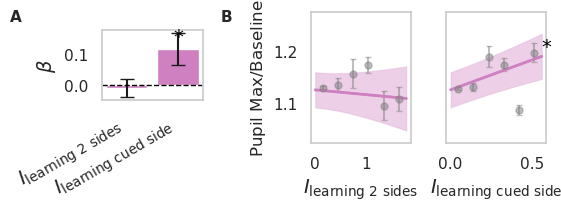

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ------------------------
def fit_pupil_model(all_pupil, predictors, dv):
    """
    Fit a mixed-effects model for one dependent variable.
    """
    formula_cols = [dv] + predictors + ["subject"]

    # force numeric
    for col in formula_cols:
        if col in all_pupil.columns:
            all_pupil[col] = pd.to_numeric(all_pupil[col], errors="coerce")

    # categorical handling
    if 'stimulus_consistency' in predictors:
        all_pupil['stimulus_consistency'] = all_pupil['stimulus_consistency'].astype(int)

    clean_data = all_pupil.dropna(subset=formula_cols)

    formula = f"{dv} ~ " + " + ".join(predictors)

    model = smf.mixedlm(
        formula,
        clean_data,
        groups=clean_data["subject"]
    ).fit(reml=True)

    return model

# ---- Predictor sets ----
model_preds = {
    "1": ["learning_surprise_bi", "learning_surprise_cued"]
}

# ---- DV we care about ----
dv = "max_pupilResponse_Ratio"

# ---- Fit models for this DV only ----
models = {}
for name, preds in model_preds.items():
    print(f"\n===== Model {name} | DV: {dv} =====")
    model = fit_pupil_model(all_pupil, preds, dv)
    models[name] = model
    print(model.summary())

# --- Selected predictors & DV ---
plot_predictors = ["learning_surprise_bi", "learning_surprise_cued"]
y_var = dv
labels_latex = [r"$I_\mathrm{learning\ 2\ sides}$", r"$I_\mathrm{learning\ cued\ side}$"]

coefs = model.params.loc[plot_predictors]
conf_int = model.conf_int().loc[plot_predictors]
pvals = model.pvalues.loc[plot_predictors]

# --- Create figure ---
fig = plt.figure(figsize=(5.5, 2), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, width_ratios=[0.6, 2], wspace=0.1, figure=fig)

# --- Panel A: Beta coefficients ---
ax_a = fig.add_subplot(gs[0])
bars = ax_a.bar(coefs.index, coefs.values,
                color="#cf80c0",
                yerr=(conf_int[1] - conf_int[0])/2,
                capsize=5)

for bar, p in zip(bars, pvals):
    if p < 0.05:
        height = bar.get_height()
        ax_a.text(bar.get_x() + bar.get_width()/2,
                  height + 0.01,
                  "*", ha='center', va='bottom', fontsize=14, color='black')

ax_a.set_ylabel(r"$\beta$", size=14)
ax_a.set_xticklabels(labels_latex, rotation=30, ha='right', size=14)
ax_a.grid(False)
ax_a.axhline(0, color='black', linewidth=1, linestyle='--')

# --- Panel B: Scatter plots with binned mean ± SEM and regression line ---
gs_b = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.1)
ax_b1 = fig.add_subplot(gs_b[0])
ax_b2 = fig.add_subplot(gs_b[1], sharey=ax_b1)

for ax, reg, label, pval in zip([ax_b1, ax_b2], plot_predictors, labels_latex, pvals):
    x = all_pupil[reg].values
    y = all_pupil[y_var].values

    # --- Binning ---
    n_bins = 6
    bins = np.linspace(np.nanmin(x), np.nanmax(x), n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    y_mean = []
    y_sem = []
    for i in range(n_bins):
        if i < n_bins - 1:
            y_bin = y[(x >= bins[i]) & (x < bins[i+1])]
        else:  # include rightmost edge for last bin
            y_bin = y[(x >= bins[i]) & (x <= bins[i+1])]
        y_bin = y_bin[~np.isnan(y_bin)]
        if len(y_bin) > 0:
            y_mean.append(np.mean(y_bin))
            y_sem.append(np.std(y_bin, ddof=1)/np.sqrt(len(y_bin)))
        else:
            y_mean.append(np.nan)
            y_sem.append(np.nan)

    # --- Plot binned mean ± SEM ---
    ax.errorbar(bin_centers, y_mean, yerr=y_sem, fmt='o', color="gray", alpha=0.5, markersize=5, capsize=2)

    # --- LME fixed-effect regression line ---
    beta_0 = model.params["Intercept"]
    beta_1 = model.params[reg]

    x_range = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_fit = beta_0 + beta_1 * x_range
    ax.plot(x_range, y_fit, color="#cf80c0", linewidth=2, label="LME fixed-effect")

    # --- 95% CI for fixed-effect prediction ---
    cov = model.cov_params().loc[
        ["Intercept", reg],
        ["Intercept", reg]
    ].values

    X_pred = np.column_stack([np.ones_like(x_range), x_range])
    var_pred = np.sum(X_pred @ cov * X_pred, axis=1)
    se_pred = np.sqrt(var_pred)

    ci_lower = y_fit - 1.96 * se_pred
    ci_upper = y_fit + 1.96 * se_pred

    ax.fill_between(
        x_range,
        ci_lower,
        ci_upper,
        color="#cf80c0",
        alpha=0.2,
        linewidth=0
    )


    ax.plot(x_range, y_fit, color="#cf80c0", label="Fixed-effect fit")
    ax.fill_between(x_range, ci_lower, ci_upper, color="#cf80c0", alpha=0.2)

    # --- Significance asterisk ---
    if pval < 0.05:
        ax.text(x_range[-1], y_fit[-1], "*", color="black", fontsize=14, va='bottom', ha='left')

    # --- Labels & grid ---
    ax.set_xlabel(label, size=14)
    ax.set_ylabel(r"$\mathrm{Pupil\ Max / Baseline}$" if ax == ax_b1 else "")
    ax.grid(False)

    # --- Auto y-limits based on binned data + SEM ---
    y_all = np.array(y_mean)
    y_err = np.array(y_sem)
    y_min = np.nanmin(y_all - y_err)
    y_max = np.nanmax(y_all + y_err)
    ax.set_ylim(y_min*0.95, y_max*1.05)

# Remove y-axis from right scatter plot
ax_b2.get_yaxis().set_visible(False)

# --- Panel labels ---
label_kw = dict(fontsize=11, fontweight="bold", va="top", ha="left", clip_on=False)
ax_a.text(-0.9, 1.3, "A", transform=ax_a.transAxes, **label_kw)
ax_b1.text(-0.9, 1.02, "B", transform=ax_b1.transAxes, **label_kw)

# --- Save figure ---
plt.savefig("response_stage.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# ------------------------
def fit_pupil_model(all_pupil, predictors, dv):
    """
    Fit a mixed-effects model for one dependent variable.
    """
    formula_cols = [dv] + predictors + ["subject"]

    # force numeric
    for col in formula_cols:
        if col in all_pupil.columns:
            all_pupil[col] = pd.to_numeric(all_pupil[col], errors="coerce")

    # categorical handling
    if 'stimulus_consistency' in predictors:
        all_pupil['stimulus_consistency'] = all_pupil['stimulus_consistency'].astype(int)

    clean_data = all_pupil.dropna(subset=formula_cols)

    formula = f"{dv} ~ " + " + ".join(predictors)

    model = smf.mixedlm(
        formula,
        clean_data,
        groups=clean_data["subject"]
    ).fit(reml=True)

    return model


# ---- Predictor sets ----
model_preds = {
    "1": ["learning_surprise_bi", "learning_surprise_cued"]
}

# ---- DV we care about ----
dv = "max_pupilResponse_Ratio"

# ---- Fit models for this DV only ----
models = {}

for name, preds in model_preds.items():
    print(f"\n===== Model {name} | DV: {dv} =====")
    model = fit_pupil_model(all_pupil, preds, dv)
    models[name] = model
    print(model.summary())

/tmp/ipykernel_2828432/1651543241.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(labels_latex, rotation=30, ha='right', size= 14)


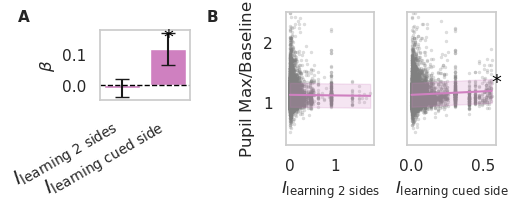

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec

# Selected predictors
plot_predictors = ["learning_surprise_bi", "learning_surprise_cued"]
y_var = "max_pupilResponse_Ratio"

# Get model coefficients, confidence intervals, and p-values
coefs = model.params.loc[plot_predictors]
conf_int = model.conf_int().loc[plot_predictors]
pvals = model.pvalues.loc[plot_predictors]

# LaTeX labels for plots
labels_latex = [r"$I_\mathrm{learning\ 2\ sides}$", r"$I_\mathrm{learning\ cued\ side}$"]

# Figure with adjusted width ratios
fig = plt.figure(figsize=(5, 2), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, width_ratios=[0.6, 2], wspace=0.1, figure=fig)

# Panel A: Beta coefficients
ax_a = fig.add_subplot(gs[0])
bars = ax_a.bar(coefs.index, coefs.values,
                color="#cf80c0",
                yerr=(conf_int[1] - conf_int[0])/2,
                capsize=5)

# Significance asterisks
for bar, p in zip(bars, pvals):
    if p < 0.05:
        height = bar.get_height()
        ax_a.text(bar.get_x() + bar.get_width()/2,
                  height + 0.01,
                  "*", ha='center', va='bottom', fontsize=14, color='black')

ax_a.set_ylabel(r"$\beta$")
ax_a.set_xticklabels(labels_latex, rotation=30, ha='right', size= 14)
ax_a.grid(False)
ax_a.axhline(0, color='black', linewidth=1, linestyle='--')

# Panel B: Scatter plots for each predictor
gs_b = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.1)
ax_b1 = fig.add_subplot(gs_b[0])
ax_b2 = fig.add_subplot(gs_b[1], sharey=ax_b1)

for ax, reg, label, pval in zip([ax_b1, ax_b2], plot_predictors, labels_latex, pvals):
    x = all_pupil[reg]
    y = all_pupil[y_var]

    # Scatter points
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.25, color="gray", s=5, edgecolor=None)

    # Regression line
    intercept = model.params["Intercept"]
    slope = model.params[reg]
    x_range = np.linspace(x.min(), x.max(), 100)
    y_fit = intercept + slope * x_range
    ax.plot(x_range, y_fit, color="#cf80c0", label="Fixed-effect fit")

    # Shaded error (using residual std)
    residuals = y - (intercept + slope * x)
    std_err = residuals.std()
    ax.fill_between(x_range, y_fit - std_err, y_fit + std_err, color="#cf80c0", alpha=0.2)

    # Significant slope asterisk
    if pval < 0.05:
        ax.text(x_range[-1], y_fit[-1], "*", color="black", fontsize=14, va='bottom', ha='left')

    ax.set_xlabel(label)
    ax.set_ylabel(r"$\mathrm{Pupil\ Max / Baseline}$" if ax == ax_b1 else "")
    ax.set_ylim(0.3, 2.5)  # <-- Set y-axis range
    ax.grid(False)

# Remove y-axis from right scatter plot
ax_b2.get_yaxis().set_visible(False)

# Panel labels
label_kw = dict(fontsize=11, fontweight="bold", va="top", ha="left", clip_on=False)
ax_a.text(-0.9, 1.3, "A", transform=ax_a.transAxes, **label_kw)
ax_b1.text(-0.9, 1.02, "B", transform=ax_b1.transAxes, **label_kw)

# Save figure
plt.savefig("response_stage.pdf", bbox_inches="tight")
plt.show()


# performance

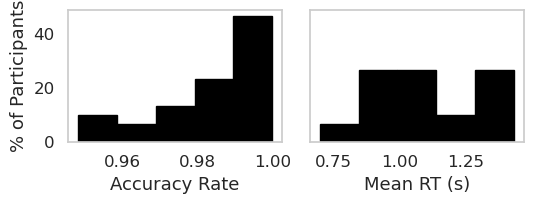

In [49]:
# import numpy as np
# import os
# import matplotlib.pyplot as plt
# import math
# import pandas as pd

# from check_qualities import CheckQuality
# import numpy as np
# import matplotlib.pyplot as plt

# import numpy as np
# import os
# import matplotlib.pyplot as plt
# import math
# import pandas as pd

# from check_qualities import CheckQuality
# import numpy as np
# import matplotlib.pyplot as plt

# rt_list = []
# incorrect_count_list = []

# for i in yes_folders:
#     participant = CheckQuality(i) 
#     incorrect_count_list.append(participant.incorrect_count)


#     rt_list_partcipant = []

#     for trial_index in range(1, 271):
#         trial_df = participant.eye_raw[
#             (participant.eye_raw['trial_index'] == trial_index) &
#             (participant.eye_raw['Type'] == 'Message')
#         ]

#         try:
#             response_time = trial_df.loc[
#                 trial_df['Event'] == 'response', 'TimeEvent'
#             ].values[0]

#             sound_start_time = trial_df.loc[
#                 trial_df['Event'] == 'start sound', 'TimeEvent'
#             ].values[0]

#             trial_rt = response_time - sound_start_time

#         except IndexError:
#             # In case response or sound start is missing
#             trial_rt = np.nan

#         rt_list_partcipant.append(trial_rt)
    
#     rt_list.append(np.mean(rt_list_partcipant))


fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.2), sharey=True)

# # Make bars black
bar_color = "black"

# Transform incorrect counts to accuracy rate
accuracy_rate_list = [(270 - x)/270 for x in incorrect_count_list]

# Accuracy rate (% of participants)
weights_acc = np.ones(len(accuracy_rate_list)) / len(accuracy_rate_list) * 100
axes[0].hist(accuracy_rate_list, bins=5, weights=weights_acc,
             color=bar_color, edgecolor="black")
axes[0].set_xlabel("Accuracy Rate", fontsize=13)
axes[0].set_ylabel("% of Participants", fontsize=13)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].grid(False)   # 👈 turn grid off

# Mean RT (% of participants)
weights_rt = np.ones(len(rt_list)) / len(rt_list) * 100
axes[1].hist(rt_list, bins=5, weights=weights_rt,
             color=bar_color, edgecolor="black")
axes[1].set_xlabel("Mean RT (s)", fontsize=13)
axes[1].set_ylabel("")  # remove right y-label
axes[1].tick_params(axis='both', labelsize=12)
axes[1].grid(False)   # 👈 turn grid off

plt.tight_layout()
# plt.suptitle("Performance Accuracy and Reaction Time Across Participants", fontsize=16, y=1.05)
# Save as PDF (vector graphic, best for LaTeX)
plt.savefig("accuracy_rt_plot.pdf", bbox_inches='tight')
plt.show()



In [23]:
np.nanmean(rt_list)

np.float64(1.0956575311251506)

In [24]:
np.median(accuracy_rate_list)*270

np.float64(267.0)

In [9]:
test.log_data

,cue_direction,stimulus,correct_response,left_cue_condition,stimA_condition,response,performance,rt,events,trial_index,wid,block_index,trial_index_within_block
0,left,B|A,j,0.5,0.7,f,Incorrect,4.442101,"[{'time': 278.24222804169403, 'event': 'initia...",1,25-09-29-1238_setting0,1,1
1,right,A|A,f,0.5,0.7,f,Correct,4.513865,"[{'time': 285.85862670838833, 'event': 'initia...",2,25-09-29-1238_setting0,1,2
2,right,B|B,j,0.5,0.7,j,Correct,4.381348,"[{'time': 293.5529617916909, 'event': 'initial...",3,25-09-29-1238_setting0,1,3
3,right,A|A,f,0.5,0.7,f,Correct,4.563732,"[{'time': 301.09968120837584, 'event': 'initia...",4,25-09-29-1238_setting0,1,4
4,right,A|A,f,0.5,0.7,f,Correct,4.336246,"[{'time': 308.8333294999902, 'event': 'initial...",5,25-09-29-1238_setting0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,left,B|B,j,0.9,0.1,j,Correct,2.439650,"[{'time': 2400.8951966249733, 'event': 'initia...",266,25-09-29-1238_setting0,9,26
266,right,B|B,j,0.9,0.1,j,Correct,2.968128,"[{'time': 2406.5120108749834, 'event': 'initia...",267,25-09-29-1238_setting0,9,27
267,left,B|B,j,0.9,0.1,j,Correct,2.986187,"[{'time': 2412.6643414166756, 'event': 'initia...",268,25-09-29-1238_setting0,9,28
268,left,B|A,j,0.9,0.1,j,Correct,3.773760,"[{'time': 2418.8295720416936, 'event': 'initia...",269,25-09-29-1238_setting0,9,29


In [15]:
test.eye_raw[(test.eye_raw['trial_index'] == 1) & (test.eye_raw['Type'] == 'Message')]

,Type,Event,Time,TimeEvent,Offset,trial_index,X,Y,Pupil,event,Start,End,Duration,Eye,Start_X,Start_Y,End_X,End_Y,Amplitude,Peak_Velocity
0,Message,initialize,163.825,278.242228,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Message,start recording,163.825,278.242414,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Message,start,163.951,278.367973,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132,Message,show fixation,163.959,278.375188,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
891,Message,show cue,164.715,279.131701,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2397,Message,show fixation,166.220,280.636579,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3159,Message,start sound,166.980,281.396675,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3587,Message,start decision window,167.480,281.896908,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5338,Message,response,169.230,283.646609,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7432,Message,done,171.422,285.838998,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
